# 02 Prepare Forecasting Data

Creates regular business-day close-price series for N-BEATS, PatchTST, Chronos, and Kronos. The models forecast close price, and the benchmark converts forecasts to future returns.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)

Project root: c:\Users\user\OneDrive\Desktop\Praktikum\Final-Project\new_equity_forecasting_project


In [2]:
from src.config import DATA_RAW_DIR, DATA_PROCESSED_DIR, FREQ
from src.data_utils import prepare_all_raw_files, load_prepared_panel

summary = prepare_all_raw_files(DATA_RAW_DIR, DATA_PROCESSED_DIR, freq=FREQ)
summary

Prepared A: 1913 rows
Prepared AAPL: 1913 rows
Prepared ABBV: 1913 rows
Prepared ABNB: 1407 rows
Prepared ABT: 1913 rows
Prepared ACN: 1913 rows
Prepared ADBE: 1913 rows
Prepared ADI: 1913 rows
Prepared AIG: 1913 rows
Prepared ALL: 1913 rows
Prepared AMAT: 1913 rows
Prepared AMD: 1913 rows
Prepared AMGN: 1913 rows
Prepared AMT: 1913 rows
Prepared AMZN: 1913 rows
Prepared APD: 1913 rows
Prepared APO: 1913 rows
Prepared ARES: 1913 rows
Prepared AUDUSD=X: 1914 rows
Prepared AVB: 1913 rows
Prepared AVGO: 1913 rows
Prepared AXP: 1913 rows
Prepared AZO: 1913 rows
Prepared BA: 1913 rows
Prepared BAC: 1913 rows
Prepared BEN: 1913 rows
Prepared BKNG: 1913 rows
Prepared BKR: 1913 rows
Prepared BLK: 1913 rows
Prepared BMY: 1913 rows
Prepared BSX: 1913 rows
Prepared BX: 1913 rows
Prepared BZ=F: 1913 rows
Prepared C: 1913 rows
Prepared CAG: 1913 rows
Prepared CAH: 1913 rows
Prepared CARR: 1597 rows
Prepared CAT: 1913 rows
Prepared CB: 1913 rows
Prepared CCI: 1913 rows
Prepared CCL: 1913 rows
Prepar

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Prepared CL=F: 1913 rows
Prepared CLX: 1913 rows
Prepared CMCSA: 1913 rows
Prepared CME: 1913 rows
Prepared CMG: 1913 rows
Prepared COP: 1913 rows
Prepared COST: 1913 rows
Prepared COTY: 1913 rows
Prepared CRM: 1913 rows
Prepared CRWD: 1798 rows
Prepared CSCO: 1913 rows
Prepared CTSH: 1913 rows
Prepared CVS: 1913 rows
Prepared CVX: 1913 rows
Prepared DDOG: 1727 rows
Prepared DE: 1913 rows
Prepared DELL: 1913 rows
Prepared DG: 1913 rows
Prepared DGX: 1913 rows
Prepared DHI: 1913 rows
Prepared DIS: 1913 rows
Prepared DLR: 1913 rows
Prepared DLTR: 1913 rows
Prepared DVN: 1913 rows
Prepared EA: 1913 rows
Prepared EBAY: 1913 rows
Prepared ECL: 1913 rows
Prepared EL: 1913 rows
Prepared EMR: 1913 rows
Prepared EOG: 1913 rows
Prepared EPAM: 1913 rows
Prepared EQIX: 1913 rows
Prepared ETN: 1913 rows
Prepared ETSY: 1913 rows
Prepared EURJPY=X: 1914 rows
Prepared EURUSD=X: 1914 rows
Prepared EW: 1913 rows
Prepared EXPE: 1913 rows
Prepared EXR: 1913 rows
Prepared F: 1913 rows
Prepared FCX: 1913 ro

,Ticker,rows,start,end
0,A,1913,2019-01-02,2026-05-01
1,AAPL,1913,2019-01-02,2026-05-01
2,ABBV,1913,2019-01-02,2026-05-01
3,ABNB,1407,2020-12-10,2026-05-01
4,ABT,1913,2019-01-02,2026-05-01
...,...,...,...,...
238,WYNN,1913,2019-01-02,2026-05-01
239,XOM,1913,2019-01-02,2026-05-01
240,YUM,1913,2019-01-02,2026-05-01
241,ZM,1837,2019-04-18,2026-05-01


In [3]:
panel = load_prepared_panel(DATA_PROCESSED_DIR)
print(panel.shape)
print(panel[['Ticker', 'Date', 'close']].head())
print(panel.groupby('Ticker').size())

(461532, 11)
  Ticker       Date      close
0      A 2019-01-02  65.690002
1      A 2019-01-03  63.270000
2      A 2019-01-04  65.459999
3      A 2019-01-07  66.849998
4      A 2019-01-08  67.830002
Ticker
A       1913
AAPL    1913
ABBV    1913
ABNB    1407
ABT     1913
        ... 
WYNN    1913
XOM     1913
YUM     1913
ZM      1837
ZS      1913
Length: 243, dtype: int64


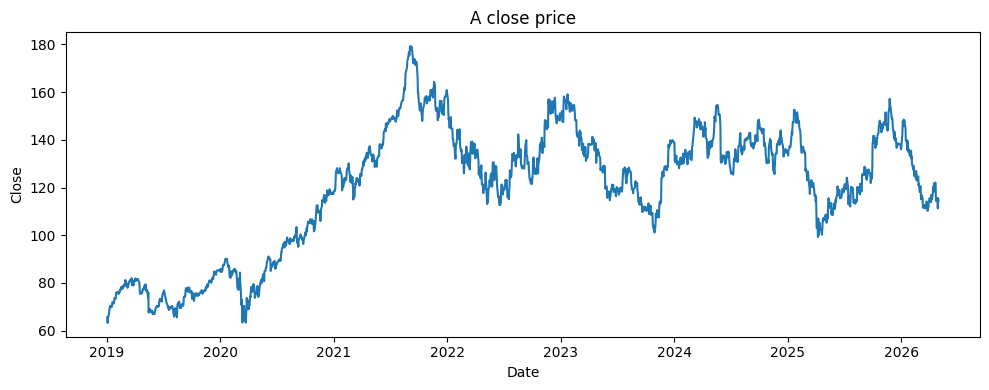

In [4]:
import matplotlib.pyplot as plt

ticker = panel['Ticker'].unique()[0]
g = panel[panel['Ticker'] == ticker]
plt.figure(figsize=(10, 4))
plt.plot(g['Date'], g['close'])
plt.title(f'{ticker} close price')
plt.xlabel('Date')
plt.ylabel('Close')
plt.tight_layout()